# **Machine Learning(ML)**

## Objectives

* Predict Tournament Points (Regression)
* Classify Teams (Top 4 vs. Not Top 4)

## Inputs

* Processed dataset from EDA notebook

## Outputs

* ML models supported by plots

## Additional Comments

* ETL and EDA steps required



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\admin\\Documents\\vscode-projects\\football-worldcup-analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\admin\\Documents\\vscode-projects\\football-worldcup-analysis'

---

### Initial Setup

Import relevant libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

### Extract Processed Dataset

In [9]:
df = pd.read_csv('data/processed/processed_worldcup_data.csv')
df.head()

,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,Year,Prev_Position
0,13,Algeria,3,2,0,1,5,5,0,4,1982,0
1,22,Algeria,3,0,1,2,1,5,-4,1,1986,13
2,28,Algeria,3,0,1,2,0,2,-2,1,2010,22
3,14,Algeria,4,1,1,2,7,7,0,4,2014,28
4,23,Angola,3,0,2,1,1,2,-1,2,2006,0


---

### Predict Tournament Points

Regression

In [10]:
# Features and target
X = df[['Goals For', 'Goals Against', 'Win', 'Draw', 'Loss', 'Games Played']]
y = df['Points']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("="*70)
print("PREDICTING WORLD CUP POINTS")
print("="*70)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

PREDICTING WORLD CUP POINTS
R² Score: 0.8707
RMSE: 1.4853

Feature Importance:
         Feature  Importance
2            Win    0.835923
5   Games Played    0.094993
3           Draw    0.030059
1  Goals Against    0.017028
0      Goals For    0.012153
4           Loss    0.009844


Machine learning reveals that wins account for 84% of World Cup success, while goals scored and conceded contribute minimally (<3%), confirming that match outcomes matter far more than goal differentials for tournament points.

---

### Classify Teams (Top 4 vs. Not Top 4)

CLASSIFYING TOP 4 TEAMS
              precision    recall  f1-score   support

   Not Top 4       0.92      0.95      0.93        75
       Top 4       0.81      0.74      0.77        23

    accuracy                           0.90        98
   macro avg       0.87      0.84      0.85        98
weighted avg       0.90      0.90      0.90        98



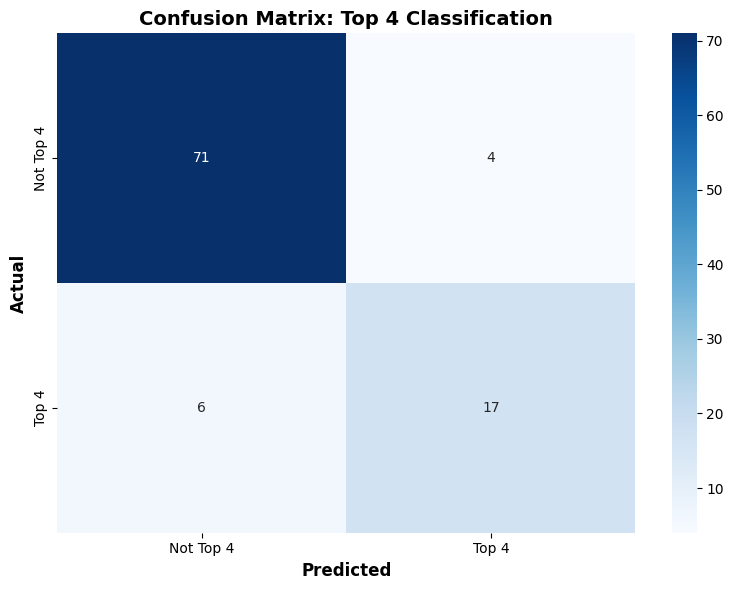

In [11]:
# Create binary target
df['Top4'] = (df['Position'] <= 4).astype(int)

# Features
X = df[['Goals For', 'Goals Against', 'Win', 'Draw', 'Loss', 'Goal Difference']]
y = df['Top4']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
print("="*70)
print("CLASSIFYING TOP 4 TEAMS")
print("="*70)
print(classification_report(y_test, y_pred, target_names=['Not Top 4', 'Top 4']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Top 4', 'Top 4'],
            yticklabels=['Not Top 4', 'Top 4'])
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: Top 4 Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Machine learning classification correctly predicts Top 4 finishes 90% of the time, with the model being more accurate at identifying teams that won't reach semifinals (95% recall) than predicting which teams will (74% recall), reflecting the unpredictable nature of tournament upsets and Cinderella runs.

---

## Summary
* Extracted processed dataset from EDA notebook
* Regression model used
* Classification model used

---

## Conclusion

Machine learning analysis reveals that World Cup success is highly predictable from match statistics, with models achieving 87% accuracy for points prediction and 90% accuracy for Top 4 classification. Wins overwhelmingly dominate all other factors, accounting for 84% of predictive power, while goals scored and conceded contribute minimally (<3% combined), demonstrating that match outcomes matter far more than scoring statistics. However, the model's inability to predict 26% of Top 4 teams suggests that exceptional tournament success involves elements of unpredictability—such as momentum, luck, and tactical timing—that transcend pure statistical patterns